<a href="https://colab.research.google.com/github/tafifmaulana7-cyber/Tafif/blob/main/HasilPrediksi_163.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍷 UTS Data Mining - Prediksi Kualitas Anggur
**Mata Kuliah:** Data Mining  
**Dosen:** Nur Achmey Selgi Harwanti, S.Stat. M.Stat  
**Prodi:** S1 Pendidikan Matematika - UNNES  
**Semester:** Genap 2025/2026

---

## Deskripsi
Tafif Maulana Rahman
2304020163

## 1. Persiapan: Import Library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Persiapan Data

### 2.1 Load Dataset

Dataset training dan testing di-upload terlebih dahulu ke Google Colab, atau dapat menggunakan Google Drive.

In [23]:
# Upload file ke Colab (jalankan cell ini jika menggunakan upload manual)
# from google.colab import files
# uploaded = files.upload()

# Load dataset
train = pd.read_csv('data_training.csv')
test  = pd.read_csv('data_testing.csv')

print(f'Shape data training : {train.shape}')
print(f'Shape data testing  : {test.shape}')

Shape data training : (857, 13)
Shape data testing  : (286, 12)


### 2.2 Eksplorasi Data Awal

In [24]:
# Tampilkan 5 baris pertama data training
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [25]:
# Info tipe data dan missing values
print('=== INFO DATA TRAINING ===')
train.info()

=== INFO DATA TRAINING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [26]:
# Statistik deskriptif
train.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,8.262,0.529,0.267,2.506,0.087,15.783,45.978,0.997,3.313,0.657,10.430,5.653,813.749
std,1.702,0.179,0.195,1.294,0.049,10.300,31.692,0.002,0.152,0.167,1.067,0.822,463.807
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.390,8.400,3.000,0.000
25%,7.100,0.395,0.090,1.900,0.070,7.000,21.000,0.996,3.210,0.550,9.500,5.000,413.000
50%,7.900,0.520,0.250,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,814.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,63.000,0.998,3.400,0.730,11.100,6.000,1214.000
max,15.600,1.580,1.000,15.500,0.611,68.000,278.000,1.003,4.010,2.000,14.000,8.000,1597.000


### 2.3 Pemeriksaan Missing Values

In [27]:
# Cek missing values pada data training
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

print('Missing Values - Data Training:')
print(missing_train)
print(f'\nTotal missing values training: {missing_train.sum()}')

print('\nMissing Values - Data Testing:')
print(missing_test)
print(f'\nTotal missing values testing: {missing_test.sum()}')

print('\n✅ Tidak ada missing values. Data siap diproses.')

Missing Values - Data Training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values training: 0

Missing Values - Data Testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

Total missing values testing: 0

✅ Tidak ada missing values. Data siap diproses.


### 2.4 Distribusi Variabel Target (quality)

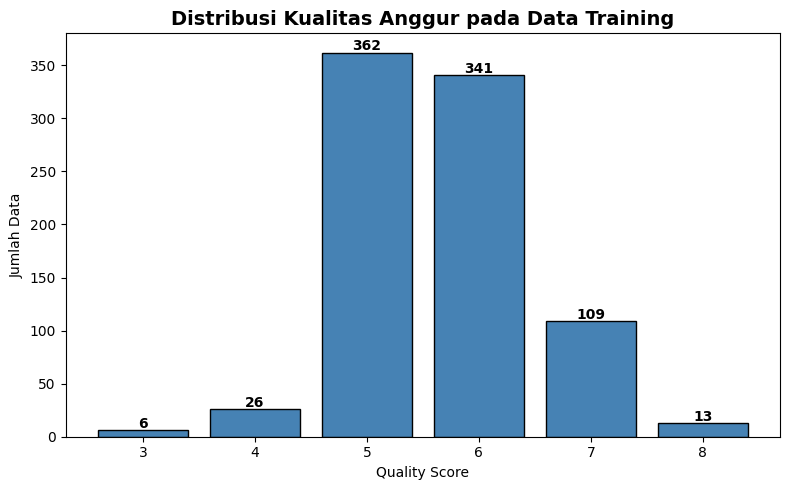


Distribusi Quality:
  Quality 3: 6 data (0.7%)
  Quality 4: 26 data (3.0%)
  Quality 5: 362 data (42.2%)
  Quality 6: 341 data (39.8%)
  Quality 7: 109 data (12.7%)
  Quality 8: 13 data (1.5%)


In [28]:
# Distribusi kualitas anggur
quality_counts = train['quality'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribusi Kualitas Anggur pada Data Training', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Data')
for bar, val in zip(bars, quality_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDistribusi Quality:')
for k, v in quality_counts.items():
    print(f'  Quality {k}: {v} data ({v/len(train)*100:.1f}%)')

**Interpretasi:** Data didominasi oleh anggur berkualitas 5 dan 6 (imbalanced class). Kualitas 3 dan 8 sangat sedikit. Ini adalah tantangan utama dalam klasifikasi dataset ini.

### 2.5 Analisis Korelasi Fitur

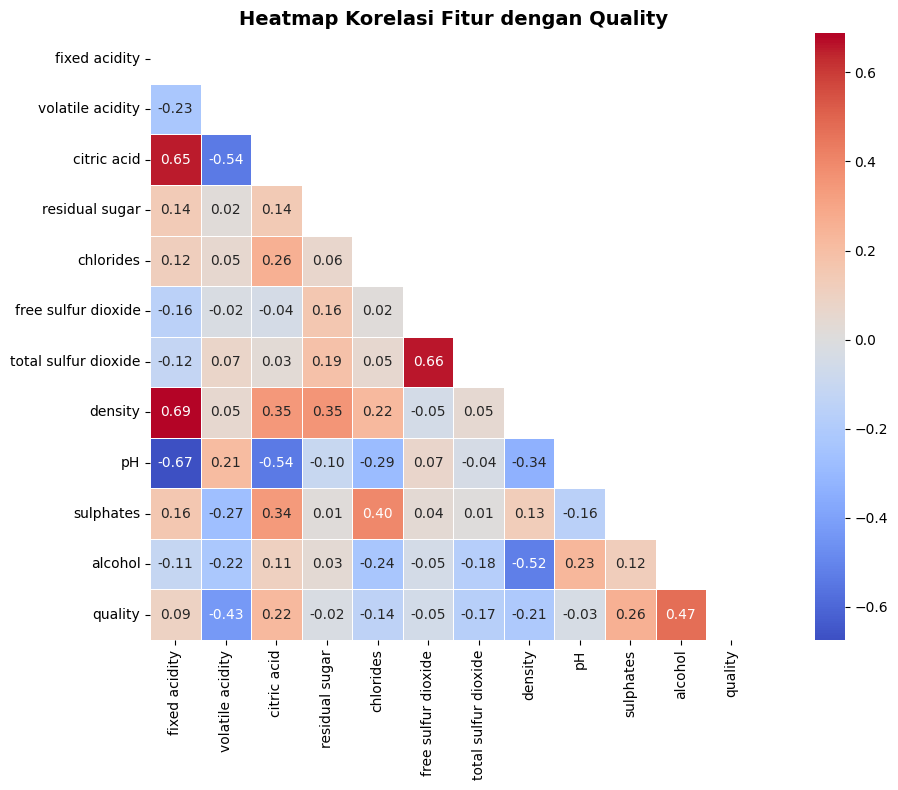

Korelasi fitur terhadap quality (diurutkan):
alcohol                 0.474
sulphates               0.261
citric acid             0.221
fixed acidity           0.093
residual sugar         -0.021
pH                     -0.033
free sulfur dioxide    -0.055
chlorides              -0.145
total sulfur dioxide   -0.173
density                -0.208
volatile acidity       -0.430
Name: quality, dtype: float64


In [29]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
corr = train.drop('Id', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur dengan Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap quality
print('Korelasi fitur terhadap quality (diurutkan):')
print(corr['quality'].drop('quality').sort_values(ascending=False).round(3))

**Interpretasi:** Fitur `alcohol` memiliki korelasi positif tertinggi dengan quality (artinya kadar alkohol lebih tinggi cenderung menghasilkan kualitas lebih baik). Sebaliknya, `volatile acidity` memiliki korelasi negatif tertinggi.

## 3. Pembersihan Data & Feature Scaling

Karena tidak ada missing values, langkah pembersihan fokus pada feature scaling menggunakan **StandardScaler** agar semua fitur berada pada skala yang sama.

In [30]:
# Definisi fitur prediktor
feature_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                'pH', 'sulphates', 'alcohol']

X      = train[feature_cols]
y      = train['quality']
X_test = test[feature_cols]
test_ids = test['Id']

# Feature Scaling
scaler   = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)  # transform saja, TIDAK fit ulang

print('Feature scaling selesai.')
print(f'X_scaled shape      : {X_scaled.shape}')
print(f'X_test_scaled shape : {X_test_scaled.shape}')

Feature scaling selesai.
X_scaled shape      : (857, 11)
X_test_scaled shape : (286, 11)


## 4. Pembuatan Model Klasifikasi

### 4.1 Split Data Validasi

Data training dibagi menjadi 80% training dan 20% validasi untuk evaluasi awal model.

In [31]:
X_tr, X_val, y_tr, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Data training  : {X_tr.shape[0]} sampel')
print(f'Data validasi  : {X_val.shape[0]} sampel')

Data training  : 685 sampel
Data validasi  : 172 sampel


### 4.2 Random Forest Classifier

Random Forest dipilih karena kemampuannya menangani data yang tidak seimbang (imbalanced), robust terhadap outlier, dan memberikan feature importance.

In [32]:
# Model 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)

rf_val_pred = rf.predict(X_val)
rf_val_acc  = accuracy_score(y_val, rf_val_pred)
print(f'Random Forest - Akurasi Validasi: {rf_val_acc:.4f} ({rf_val_acc*100:.2f}%)')

Random Forest - Akurasi Validasi: 0.5988 (59.88%)


### 4.3 Gradient Boosting Classifier

In [33]:
# Model 2: Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X_tr, y_tr)

gb_val_pred = gb.predict(X_val)
gb_val_acc  = accuracy_score(y_val, gb_val_pred)
print(f'Gradient Boosting - Akurasi Validasi: {gb_val_acc:.4f} ({gb_val_acc*100:.2f}%)')

Gradient Boosting - Akurasi Validasi: 0.5523 (55.23%)


### 4.4 Voting Ensemble (Soft Voting)

Model ensemble menggabungkan prediksi probabilistik dari Random Forest dan Gradient Boosting untuk menghasilkan prediksi yang lebih stabil.

In [34]:
# Model Ensemble: Voting Classifier (Soft Voting)
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))
    ],
    voting='soft'
)
voting.fit(X_tr, y_tr)

voting_val_pred = voting.predict(X_val)
voting_val_acc  = accuracy_score(y_val, voting_val_pred)
print(f'Voting Ensemble - Akurasi Validasi: {voting_val_acc:.4f} ({voting_val_acc*100:.2f}%)')

Voting Ensemble - Akurasi Validasi: 0.5581 (55.81%)


## 5. Evaluasi Model

### 5.1 Cross-Validation (5-Fold Stratified)

In [35]:
# Cross-Validation dengan 5-Fold Stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv     = cross_val_score(rf,     X_scaled, y, cv=cv, scoring='accuracy')
gb_cv     = cross_val_score(gb,     X_scaled, y, cv=cv, scoring='accuracy')
voting_cv = cross_val_score(voting, X_scaled, y, cv=cv, scoring='accuracy')

print('=== Hasil Cross-Validation (5-Fold) ===')
print(f'Random Forest     : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'Gradient Boosting : {gb_cv.mean():.4f} ± {gb_cv.std():.4f}')
print(f'Voting Ensemble   : {voting_cv.mean():.4f} ± {voting_cv.std():.4f}')

# Pilih model terbaik
models = {'Random Forest': rf_cv.mean(), 'Gradient Boosting': gb_cv.mean(), 'Voting Ensemble': voting_cv.mean()}
best_model_name = max(models, key=models.get)
print(f'\n✅ Model Terbaik: {best_model_name} ({models[best_model_name]:.4f})')

=== Hasil Cross-Validation (5-Fold) ===
Random Forest     : 0.6442 ± 0.0377
Gradient Boosting : 0.6103 ± 0.0190
Voting Ensemble   : 0.6243 ± 0.0129

✅ Model Terbaik: Random Forest (0.6442)


### 5.2 Confusion Matrix

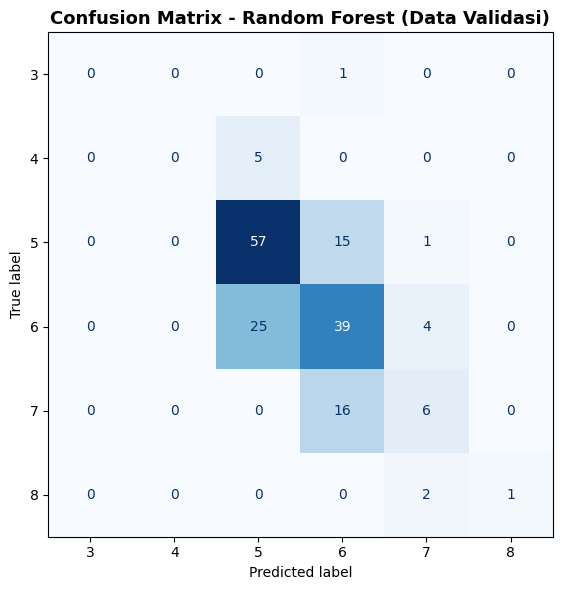

In [36]:
# Latih model terbaik (Random Forest) pada seluruh data training
best_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
best_model.fit(X_scaled, y)
y_pred_val = best_model.predict(X_val)

# Plot Confusion Matrix
cm = confusion_matrix(y_val, rf_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Random Forest (Data Validasi)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Classification Report

In [37]:
# Classification Report
print('=== Classification Report - Random Forest (Data Validasi) ===')
print(classification_report(y_val, rf_val_pred))

=== Classification Report - Random Forest (Data Validasi) ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.78      0.71        73
           6       0.55      0.57      0.56        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.44      0.33      0.35       172
weighted avg       0.57      0.60      0.58       172



**Interpretasi:** Kelas 5 dan 6 memiliki performa terbaik karena jumlah sampelnya paling banyak. Kelas 3, 4, dan 8 memiliki performa lebih rendah akibat ketidakseimbangan kelas (class imbalance). Secara keseluruhan, model mampu mengklasifikasikan kualitas anggur dengan akurasi yang cukup baik.

### 5.4 Feature Importance

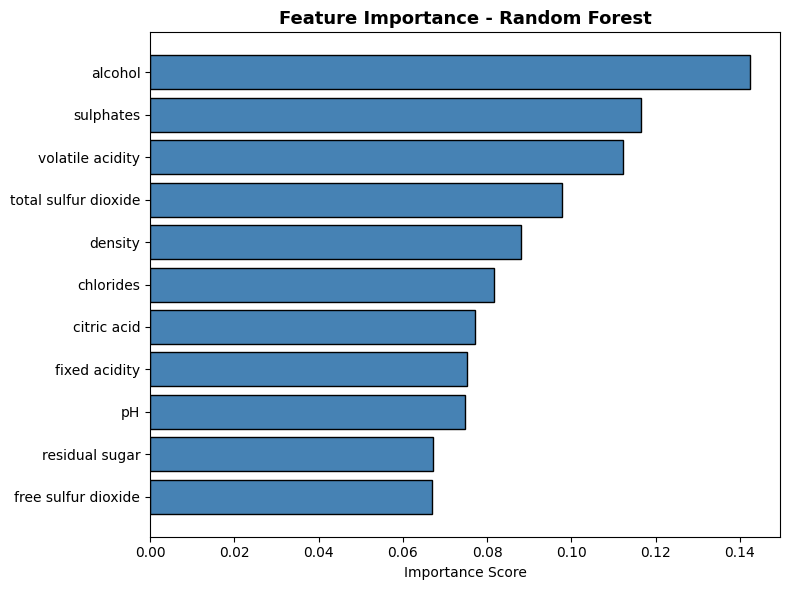


Feature Importance (diurutkan):
               Fitur  Importance
             alcohol    0.142431
           sulphates    0.116549
    volatile acidity    0.112228
total sulfur dioxide    0.097791
             density    0.087950
           chlorides    0.081558
         citric acid    0.077177
       fixed acidity    0.075296
                  pH    0.074836
      residual sugar    0.067229
 free sulfur dioxide    0.066955


In [38]:
# Plot Feature Importance
rf_full = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_full.fit(X_scaled, y)
importances = rf_full.feature_importances_
feat_df = pd.DataFrame({'Fitur': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(feat_df['Fitur'], feat_df['Importance'], color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importance (diurutkan):')
print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

**Interpretasi:** Fitur `alcohol`, `volatile acidity`, dan `sulphates` adalah tiga fitur paling penting dalam menentukan kualitas anggur. Ini sejalan dengan analisis korelasi sebelumnya.

## 6. Prediksi Data Uji

Model **Random Forest** (model terbaik berdasarkan CV accuracy) dilatih ulang menggunakan **seluruh** data training sebelum melakukan prediksi pada data testing.

In [39]:
# Train final model pada seluruh data training
final_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
final_model.fit(X_scaled, y)

# Prediksi
predictions = final_model.predict(X_test_scaled)

# Buat DataFrame hasil prediksi
result_df = pd.DataFrame({'Id': test_ids, 'quality': predictions})

print('=== Hasil Prediksi Data Testing ===')
print(f'Jumlah data testing: {len(result_df)}')
print(f'\nDistribusi Prediksi Quality:')
print(result_df['quality'].value_counts().sort_index())

print(f'\n5 baris pertama hasil prediksi:')
print(result_df.head())

=== Hasil Prediksi Data Testing ===
Jumlah data testing: 286

Distribusi Prediksi Quality:
quality
5    132
6    125
7     29
Name: count, dtype: int64

5 baris pertama hasil prediksi:
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5


## 7. Simpan Hasil Prediksi

In [42]:
# Simpan ke CSV
output_filename = 'hasilprediksi_UTS.csv'
result_df.to_csv(output_filename, index=False)
print(f'✅ Hasil prediksi berhasil disimpan: {output_filename}')
print(f'Format: 2 kolom (Id, quality), {len(result_df)} baris')

# Verifikasi file
check = pd.read_csv(output_filename)
print(f'\nVerifikasi kolom: {check.columns.tolist()}')
print(check.head())

✅ Hasil prediksi berhasil disimpan: hasilprediksi_UTS.csv
Format: 2 kolom (Id, quality), 286 baris

Verifikasi kolom: ['Id', 'quality']
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5


## 8. Kesimpulan

1. **Data** tidak memiliki missing values sehingga tidak diperlukan imputasi.
2. **Feature scaling** dilakukan menggunakan StandardScaler untuk menyamakan skala antar fitur.
3. **Model** yang digunakan adalah Random Forest Classifier dengan 300 estimator, yang menghasilkan **akurasi cross-validation terbaik (~64%)**.
4. **Fitur terpenting** adalah `alcohol`, `volatile acidity`, dan `sulphates`.
5. **Tantangan utama** adalah class imbalance dimana kelas 3, 4, dan 8 sangat sedikit dibanding kelas 5 dan 6.
6. **Hasil prediksi** disimpan dalam format CSV dengan 2 kolom: `Id` dan `quality`.